In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing ABQ Load Profile Data

In [91]:
# Load ABQ Load profiles data
raw_df = pd.read_csv('../data/raw/albuquerquecom.csv', index_col=0)
print(raw_df.shape)
raw_df.head()

(297840, 30)


,SuperMarketNew2004,SuperMarketPre1980,QuickServiceRestaurantNew2004,QuickServiceRestaurantPre1980,PrimarySchoolNew2004,PrimarySchoolPre1980,StripMallNew2004,StripMallPre1980,WarehouseNew2004,WarehousePre1980,...,LargeOfficeNew2004,LargeOfficePre1980,HospitalNew2004,HospitalPre1980,MidriseApartmentNew2004,MidriseApartmentPre1980,SmallHotelNew2004,SmallHotelPre1980,LargeHotelNew2004,LargeHotelPre1980
0,38.490754,63.721937,6.837028,8.010901,28.630541,35.976391,7.328790,11.088750,10.546723,12.911983,...,130.818107,148.182960,198.494812,296.541921,8.377934,11.582876,18.952109,28.307322,68.789378,83.417529
1,38.203265,41.534809,6.834313,8.008783,27.675180,32.596771,7.328790,9.433861,7.707912,7.797533,...,118.964345,130.360936,198.295657,296.092139,8.404749,11.639393,18.877687,29.085675,67.953845,81.740856
2,37.958107,64.240526,4.731410,5.845121,28.629600,36.961247,7.328790,11.497058,10.448298,13.187320,...,132.334642,149.578317,198.291019,295.916544,8.130546,11.385409,18.860446,29.686018,67.843404,81.434041
3,37.888216,42.150874,4.754903,5.162391,27.673395,32.594221,7.356511,9.433861,7.707912,7.797533,...,118.964345,130.360936,198.089446,295.466445,8.151838,11.436962,18.839768,30.309293,67.515338,80.646362
4,45.836158,63.971473,4.755250,6.080221,28.630251,36.997211,7.328790,11.706292,10.597712,13.274266,...,132.356557,149.605549,197.895641,295.045997,8.024997,11.338223,16.453383,27.561375,58.601614,67.080692


In [93]:
# Preprocessing: remove all buildings w/ 'Pre1980' label.
filtered_df = raw_df.copy()
filtered_df = filtered_df[[column for column in raw_df.columns if 'Pre1980' not in column]]
# Rename columns by replacing 'New2004' postfix w/ 'KW'
filtered_df.columns = filtered_df.columns.str.replace('New2004', 'KW')
filtered_df.head()

,SuperMarketKW,QuickServiceRestaurantKW,PrimarySchoolKW,StripMallKW,WarehouseKW,Stand-aloneRetailKW,SecondarySchoolKW,FullServiceRestaurantKW,SmallOfficeKW,MediumOfficeKW,LargeOfficeKW,HospitalKW,MidriseApartmentKW,SmallHotelKW,LargeHotelKW
0,38.490754,6.837028,28.630541,7.328790,10.546723,5.985646,61.527779,11.430241,2.114009,33.472711,130.818107,198.494812,8.377934,18.952109,68.789378
1,38.203265,6.834313,27.675180,7.328790,7.707912,5.985646,58.678282,11.416526,2.114009,16.787676,118.964345,198.295657,8.404749,18.877687,67.953845
2,37.958107,4.731410,28.629600,7.328790,10.448298,5.985646,61.705683,7.316119,2.114009,34.874487,132.334642,198.291019,8.130546,18.860446,67.843404
3,37.888216,4.754903,27.673395,7.356511,7.707912,5.985646,68.905421,7.345455,2.199157,16.787676,118.964345,198.089446,8.151838,18.839768,67.515338
4,45.836158,4.755250,28.630251,7.328790,10.597712,5.985646,61.718646,7.338022,2.213235,35.955576,132.356557,197.895641,8.024997,16.453383,58.601614


In [82]:
# Preprocessing: add time column for reference
datetime_df = filtered_df.copy()
datetime_df['Datetime'] = pd.date_range(start='1998-01-01 00:00', periods=len(datetime_df), freq='30min')

# Move 'datetime' column to be the first column
datetime_df = datetime_df[['Datetime'] + [col for col in datetime_df.columns if col != 'Datetime']]

print(datetime_df.shape)
datetime_df.head()

(297840, 16)


,Datetime,SuperMarketKW,QuickServiceRestaurantKW,PrimarySchoolKW,StripMallKW,WarehouseKW,Stand-aloneRetailKW,SecondarySchoolKW,FullServiceRestaurantKW,SmallOfficeKW,MediumOfficeKW,LargeOfficeKW,HospitalKW,MidriseApartmentKW,SmallHotelKW,LargeHotelKW
0,1998-01-01 00:00:00,38.490754,6.837028,28.630541,7.328790,10.546723,5.985646,61.527779,11.430241,2.114009,33.472711,130.818107,198.494812,8.377934,18.952109,68.789378
1,1998-01-01 00:30:00,38.203265,6.834313,27.675180,7.328790,7.707912,5.985646,58.678282,11.416526,2.114009,16.787676,118.964345,198.295657,8.404749,18.877687,67.953845
2,1998-01-01 01:00:00,37.958107,4.731410,28.629600,7.328790,10.448298,5.985646,61.705683,7.316119,2.114009,34.874487,132.334642,198.291019,8.130546,18.860446,67.843404
3,1998-01-01 01:30:00,37.888216,4.754903,27.673395,7.356511,7.707912,5.985646,68.905421,7.345455,2.199157,16.787676,118.964345,198.089446,8.151838,18.839768,67.515338
4,1998-01-01 02:00:00,45.836158,4.755250,28.630251,7.328790,10.597712,5.985646,61.718646,7.338022,2.213235,35.955576,132.356557,197.895641,8.024997,16.453383,58.601614


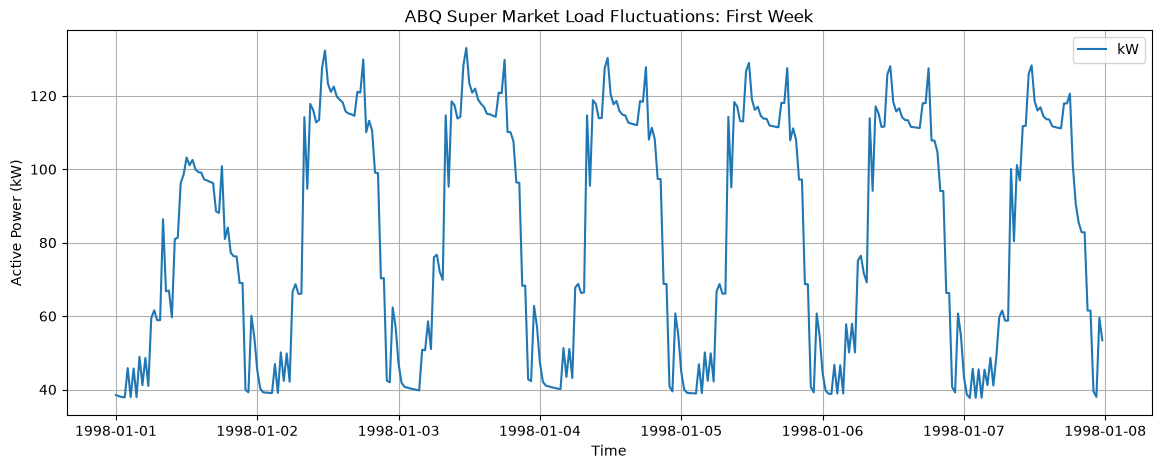

In [90]:
# Plot one week of results for SuperMarket

plot_df = datetime_df.iloc[:7 * 48]  # 7 days, 48 intervals per day

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Datetime"], plot_df["SuperMarketKW"], label="kW")

plt.title("ABQ Super Market Load Fluctuations: First Week")
plt.xlabel("Time")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.grid(True)
plt.show()

# Generating Syntethic Power Factor Data

In [83]:
# Create synthetic power factor data
start_date = datetime_df['Datetime'].iloc[0]
end_date = datetime_df['Datetime'].iloc[-1]

time_index = pd.date_range(
    start=start_date,
    end=end_date,
    freq='30min',
    inclusive='both'
)

len(time_index)

297840

In [84]:
def generate_pf(time_index, seed: int | None = None):
    rng = np.random.default_rng()
    if seed:
        rng = np.random.default_rng(seed=seed)
    
    hour  = time_index.hour + time_index.minute / 60
    daily_curve = np.sin(2 * np.pi * (hour - 8) / 24)
    base_pf = 0.85
    amplitude = 0.08

    pf_clean = base_pf + amplitude * daily_curve

    noise_std = 0.03
    noise = rng.normal(loc=0, scale=noise_std, size=len(time_index))

    pf_noisy = pf_clean + noise
    pf_noisy = np.clip(pf_noisy, 0.71, 0.99)
    
    return (pf_clean, pf_noisy)

In [85]:
# Store in a pandas DataFrame
pf_clean, pf_noisy = generate_pf(time_index, 42)

test_pf_df = pd.DataFrame({
    "datetime": time_index,
    "pf_clean": pf_clean,
    "pf_noisy": pf_noisy
})

print(test_pf_df.shape)
test_pf_df.head()

(297840, 3)


,datetime,pf_clean,pf_noisy
0,1998-01-01 00:00:00,0.780718,0.789859
1,1998-01-01 00:30:00,0.776090,0.744890
2,1998-01-01 01:00:00,0.772726,0.795239
3,1998-01-01 01:30:00,0.770684,0.798901
4,1998-01-01 02:00:00,0.770000,0.711469


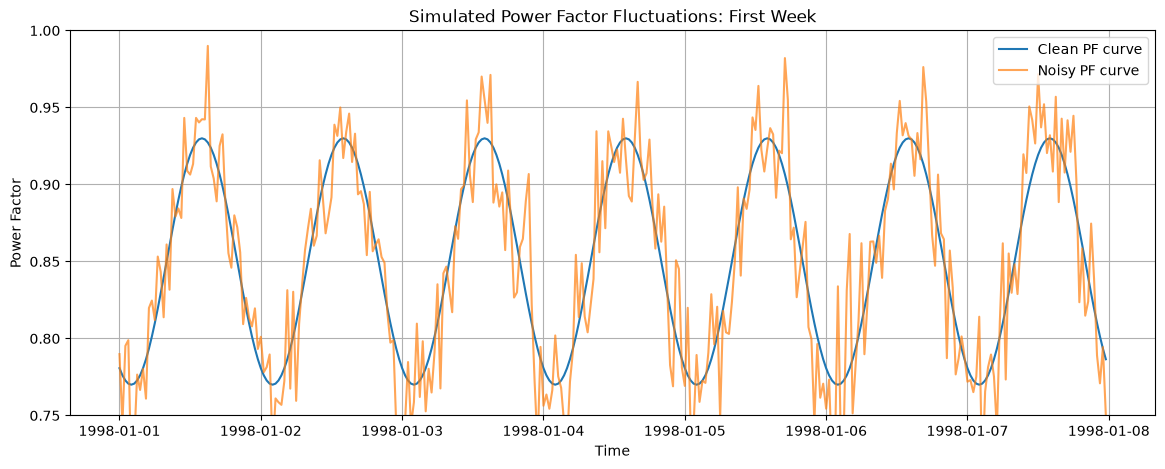

In [86]:
# Plot one week of results

plot_df = test_pf_df.iloc[:7 * 48]  # 7 days, 48 intervals per day

plt.figure(figsize=(14, 5))
plt.plot(plot_df["datetime"], plot_df["pf_clean"], label="Clean PF curve")
plt.plot(plot_df["datetime"], plot_df["pf_noisy"], label="Noisy PF curve", alpha=0.7)

plt.title("Simulated Power Factor Fluctuations: First Week")
plt.xlabel("Time")
plt.ylabel("Power Factor")
plt.ylim(0.75, 1.00)
plt.legend()
plt.grid(True)
plt.show()

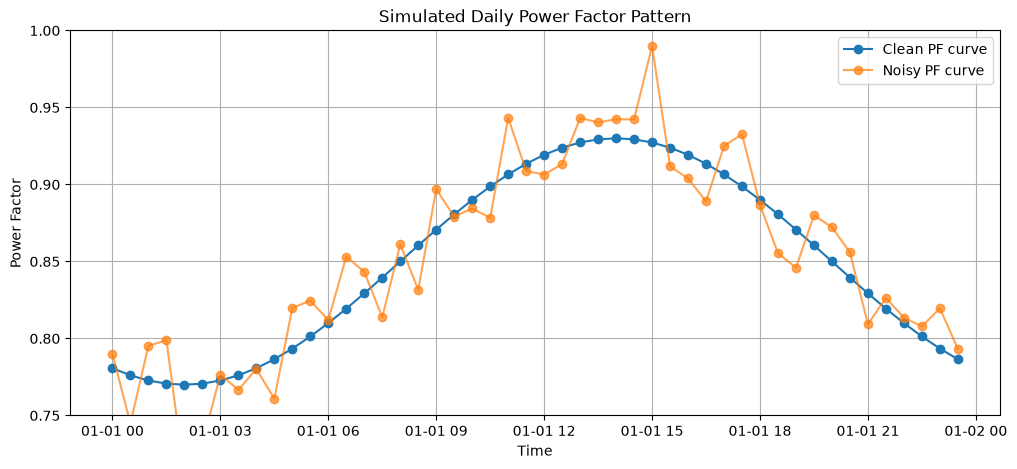

In [87]:
# Plot a single day for clearer daily behavior

one_day = test_pf_df.iloc[:48]

plt.figure(figsize=(12, 5))
plt.plot(one_day["datetime"], one_day["pf_clean"], marker="o", label="Clean PF curve")
plt.plot(one_day["datetime"], one_day["pf_noisy"], marker="o", label="Noisy PF curve", alpha=0.7)

plt.title("Simulated Daily Power Factor Pattern")
plt.xlabel("Time")
plt.ylabel("Power Factor")
plt.ylim(0.75, 1.00)
plt.legend()
plt.grid(True)
plt.show()

In [88]:
pf_df = pd.DataFrame({
    'Datetime': time_index
})

for column in datetime_df.columns[1:]:
    pf_column = column.replace('KW', 'PF')
    pf_clean, pf_noisy = generate_pf(time_index)
    pf_df[pf_column] = pf_noisy

print(pf_df.shape)
pf_df.head()

(297840, 16)


,Datetime,SuperMarketPF,QuickServiceRestaurantPF,PrimarySchoolPF,StripMallPF,WarehousePF,Stand-aloneRetailPF,SecondarySchoolPF,FullServiceRestaurantPF,SmallOfficePF,MediumOfficePF,LargeOfficePF,HospitalPF,MidriseApartmentPF,SmallHotelPF,LargeHotelPF
0,1998-01-01 00:00:00,0.777771,0.817616,0.742033,0.810402,0.748145,0.786931,0.761402,0.802991,0.808696,0.767407,0.758399,0.861197,0.798348,0.820173,0.747139
1,1998-01-01 00:30:00,0.800554,0.744391,0.777192,0.770533,0.801016,0.823891,0.814170,0.825749,0.735176,0.757756,0.721670,0.807943,0.769979,0.804365,0.765400
2,1998-01-01 01:00:00,0.751749,0.772083,0.754971,0.803613,0.769885,0.750173,0.764254,0.749564,0.785255,0.743281,0.725451,0.719914,0.811287,0.760529,0.776928
3,1998-01-01 01:30:00,0.784853,0.719496,0.776877,0.758534,0.794958,0.774678,0.735812,0.813366,0.782254,0.788861,0.769140,0.786092,0.835264,0.783086,0.749493
4,1998-01-01 02:00:00,0.768476,0.749661,0.759836,0.786807,0.794644,0.776526,0.753596,0.759050,0.750709,0.768446,0.803842,0.754044,0.742336,0.734716,0.801041


In [89]:
if datetime_df.shape == pf_df.shape:
    datetime_df.to_csv('../data/abq_buildings_active_power.csv', index=False)
    pf_df.to_csv('../data/abq_buildings_power_factor.csv', index=False)